In [16]:
import numpy as np
import copy
import gfapy
import networkx as nx
import re
from functools import reduce
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

from sympy import Symbol, Poly, S
import sympy as sp

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

In [2]:
S.One

1

In [3]:
filename = '/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/trivial.gfa'
gfa = gfapy.Gfa.from_file(filename, vlevel=0)


In [4]:
graph = nx.DiGraph()
for index, segment_line in enumerate(gfa.segments):
    graph.add_node(f'{segment_line.name}_+', weight=segment_line.SC, start=segment_line.st)
    graph.add_node(f'{segment_line.name}_-', weight=segment_line.SC, start=segment_line.st)
for edge_line in gfa.edges:
    v1 = edge_line.sid1
    v2 = edge_line.sid2
    graph.add_edges_from([
        (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
    ])
    v1.invert()
    v2.invert()
    graph.add_edges_from([
        (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
    ])

nodes = list(graph.nodes)
N = len(nodes)
n = int(np.ceil(np.log2(N+1)))
total_weight = int(sum(graph.nodes[node]["weight"] for node in nodes) / 2)
T = int(1.1 * total_weight)

In [5]:
nodes

['u0_+', 'u0_-', 'u1_+', 'u1_-', 'u2_+', 'u2_-']

In [6]:
class Binary(Symbol):
    def _eval_power(self, other):
        return self

In [18]:
sp.Pow(2,0)

1

In [19]:
class Ising(Symbol):
    def _eval_power(self, other):
        return self if other % 2 == 1 else sp.Pow(self, 0)

In [20]:
x = [[Binary(f'x[{t}][{i}]') for i in range(n)] for t in range(T)]
x

[[x[0][0], x[0][1], x[0][2]],
 [x[1][0], x[1][1], x[1][2]],
 [x[2][0], x[2][1], x[2][2]]]

In [21]:
Z = [Ising(f"Z[{i}]") for i in range(n*T)]
Z


[Z[0], Z[1], Z[2], Z[3], Z[4], Z[5], Z[6], Z[7], Z[8]]

In [23]:
Z[0]**3

Z[0]

In [24]:
def bin_rep(k):
    return [int(x) for x in np.binary_repr(k, n)[::-1]]

1 - (0.5 - Z/2) - b + 2(0.5-Z/2)b = 0.5 + Z/2 - bZ = 1/2 ( 1 + (1-b) * Z )

b = 0 => Z = -1
b = 1 => Z = 1

In [25]:
def indices_to_pauli(t, k):
    p = ['I'] * n * T
    p[t*n + k] = 'Z'
    return SparsePauliOp(''.join(p), 1)

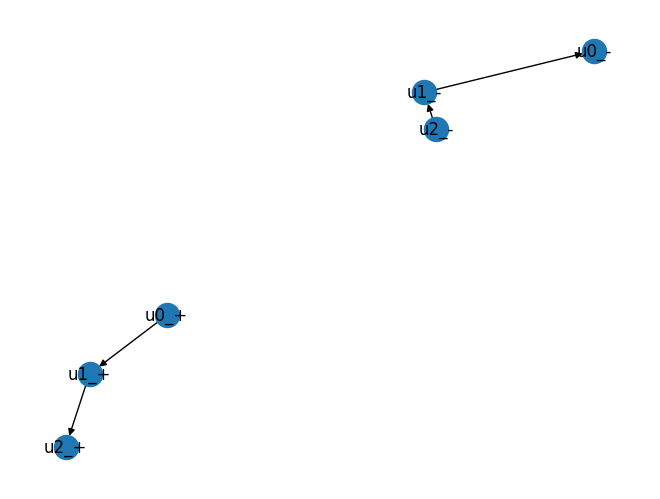

In [26]:
nx.draw(graph, with_labels=True)

In [27]:
cons_spo = reduce(
    SparsePauliOp._add,
    [
        SparsePauliOp('I'*n*T, 1) - reduce(
            SparsePauliOp._add,
            [
                SparsePauliOp.compose(
                    reduce(
                        SparsePauliOp.compose,
                        [0.5 * (SparsePauliOp('I' * n * T, 1) + (1 - 2 * bin_rep(i)[k]) * indices_to_pauli(t, k)) for k in range(n)],
                        SparsePauliOp('I'*n*T, 1)
                    ),
                    reduce(
                        SparsePauliOp._add,
                        [
                            reduce(
                                SparsePauliOp.compose,
                                [0.5 * (SparsePauliOp('I' * n * T, 1) + (1 - 2 * bin_rep(j)[k]) * indices_to_pauli(t+1, k)) for k in range(n)],
                                SparsePauliOp('I'*n*T, 1)
                            )
                            for j in [nodes.index(nbr) for nbr in graph.neighbors(nodes[i])]
                        ],
                        SparsePauliOp('I'*n*T, 0)
                    )
                )
                for i in range(N)
            ],
            SparsePauliOp('I'*n*T, 0)
        ) for t in range(T-1) 
    ],
    SparsePauliOp('I'*n*T, 0)
)



In [28]:
obj_spo = reduce(
    SparsePauliOp._add,
    [
        (
            reduce(
                SparsePauliOp._add,
                [
                    reduce(
                        SparsePauliOp.compose,
                        [0.5 * (SparsePauliOp('I' * n * T, 1) + (1 - 2 * bin_rep(i)[k]) * indices_to_pauli(t, k)) for k in range(n)]
                    ) + reduce(
                        SparsePauliOp.compose,
                        [0.5 * (SparsePauliOp('I' * n * T, 1) + (1 - 2 * bin_rep(i+1)[k]) * indices_to_pauli(t, k)) for k in range(n)]
                    )
                    for t in range(T)
                ],
                SparsePauliOp('I'  * n * T, 0)
            ) 
            - SparsePauliOp('I' * n * T, graph.nodes[nodes[i]]["weight"]) 
        ) ** 2
        for i in range(0, N, 2)
    ],
    SparsePauliOp('I'  * n * T, 0)
)


In [29]:
constraint: Poly = sum([
    1 - sum([
        np.prod([
            1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
        for k in range(n)]) * sum([
            np.prod([
                1 - x[t+1][k] - bin_rep(j)[k] + 2 * x[t+1][k] * bin_rep(j)[k]
            for k in range(n)])
        for j in [nodes.index(nbr) for nbr in graph.neighbors(nodes[i])]])
    for i in range(N)])
for t in range(T-1)])

In [30]:
obj: Poly = sum([
    (
        sum([
            np.prod([
                1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
            for k in range(n)])
            + np.prod([
                1 - x[t][k] - bin_rep(i+1)[k] + 2 * x[t][k] * bin_rep(i+1)[k]
            for k in range(n)])
        for t in range(T)])
        - graph.nodes[nodes[i]]["weight"]
    ) ** 2
for i in range(0,N,2)])

In [54]:
lamda = 10
total = lamda * constraint + obj
# total = Poly(total, domain='ZZ')
# total

In [55]:
ising = total.subs(zip([item for row in x for item in row], [0.5 - z/2 for z in Z]))
ising = Poly(ising, Z)
expr = ising.as_expr()

In [56]:
def monomial_to_pauli(monomial):
    indices = [int(re.search(r'[0-9]+', atom.name).group(0)) for atom in monomial.atoms()]
    pauli_str = ['I'] * n * T
    for i in indices:
        pauli_str[i] = 'Z'
    return ''.join(pauli_str)

In [57]:
hamiltonian = SparsePauliOp('I'*n*T, expr.as_coefficients_dict()[1])
for (monomial, coeff) in expr.as_coefficients_dict().items():
    if monomial == 1:
        continue
    hamiltonian += SparsePauliOp(monomial_to_pauli(monomial), coeff)

In [58]:
hamiltonian = hamiltonian.simplify()
hamiltonian = hamiltonian.sort(weight=True)

In [59]:
new_ham = 10*cons_spo + obj_spo
new_ham = new_ham.simplify()
new_ham = new_ham.sort(weight=True)

In [60]:
diff_ham = hamiltonian - new_ham
diff_ham = diff_ham.simplify()
np.nonzero(diff_ham.coeffs)

(array([], dtype=int64),)

In [41]:
cons_ising = constraint.subs(zip([item for row in x for item in row], [0.5 - z/2 for z in Z]))
cons_ising = Poly(cons_ising, Z)
cons_expr = cons_ising.as_expr()

In [42]:
cons_ham = SparsePauliOp('I'*n*T, cons_expr.as_coefficients_dict()[1])
for (monomial, coeff) in cons_expr.as_coefficients_dict().items():
    if monomial == 1:
        continue
    cons_ham += SparsePauliOp(monomial_to_pauli(monomial), coeff)

In [43]:
cons_ham = cons_ham.simplify()

cons_spo = cons_spo.simplify()

diff_cons = cons_ham - cons_spo
diff_cons = diff_cons.simplify()
np.nonzero(diff_cons.coeffs)

(array([], dtype=int64),)

In [44]:
obj_ising = obj.subs(zip([item for row in x for item in row], [0.5 - z/2 for z in Z]))
obj_ising = Poly(obj_ising, Z)
obj_expr = obj_ising.as_expr()

In [46]:
obj_ham = SparsePauliOp('I'*n*T, obj_expr.as_coefficients_dict()[1])
for (monomial, coeff) in obj_expr.as_coefficients_dict().items():
    if monomial == 1:
        continue
    obj_ham += SparsePauliOp(monomial_to_pauli(monomial), coeff)

In [48]:
obj_ham = obj_ham.simplify()
obj_ham = obj_ham.sort(weight=True)

obj_spo = obj_spo.simplify()
obj_spo = obj_spo.sort(weight=True)


diff_obj = obj_ham - obj_spo
diff_obj = diff_obj.simplify()

# print(obj_ham.paulis[np.nonzero(obj_ham.coeffs)])
# print(obj_spo.paulis[np.nonzero(obj_spo.coeffs)])
# print(diff_obj.paulis[np.nonzero(diff_obj.coeffs)])
np.nonzero(diff_obj.coeffs)

(array([], dtype=int64),)

In [ ]:
qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = 1,
    flatten=True
)

In [ ]:
# qc.draw(fold=-1)

In [ ]:
def two_qubit_count(qc):
    return qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)

def depth(qc):
    return qc.depth(lambda instr: len(instr.qubits) > 1)

In [ ]:
print(two_qubit_count(qc))
print(depth(qc))
print(qc.num_qubits)

In [ ]:
backend_options = dict(
    method='statevector',
    # device='GPU',
    # cuStateVec_enable=True,
    # blocking_enable=True,
    # blocking_qubits=24,
    # batched_shots_gpu_max_qubits=24,
    precision='single'
)
fake_fez = FakeFez()
backend = AerSimulator.from_backend(fake_fez, **backend_options)

In [ ]:
tqc = transpile(qc, backend, optimization_level=3)

In [ ]:
print(two_qubit_count(tqc))
print(depth(tqc))

In [ ]:
def circuit_to_graph(qc: QuantumCircuit, parameter) -> nx.Graph:
    """"QAOA Cost operator as a circuit to a graph"""
    print(parameter)
    qreg = qc.qregs[0]
    graph, edges = nx.Graph(), []
    graph.add_nodes_from(range(len(qreg)))
    seen_edges = set()

    for inst in qc.data:
        iop = inst.operation
        if len(iop.params) == 0 or parameter not in iop.params[0].parameters:
            continue

        if len(inst.qubits) == 1:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[0]))
        elif len(inst.qubits) == 2:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[1]))
        else:
            raise ValueError('Too many qubits in instruction')
        
        if edge in seen_edges:
            raise ValueError(f'Circuit contains edge {edge} multiple times')

        print(edge)
        seen_edges.add(edge)
        seen_edges.add(edge[::-1])

        param_expression = copy.deepcopy(iop.params[0])
        param_expression = param_expression.assign(next(iter(param_expression.parameters)), 1)
        weight = float(param_expression) / 2.0
        print(weight)
        edges.append((edge[0], edge[1], weight))

    graph.add_weighted_edges_from(edges)
    return graph

In [ ]:
# res = np.array([
#     [ 12, 429, 779],
#     [ 16, 3150, 4668],
#     [ 20, 11790, 15337],
#     [ 24, 6731, 9962],
#     [30, 25588, 32093],
#     [30, 35061, 42029],
#     [35, 45577, 55537]
# ])

res = np.array([
    [ 12, 429, 779],
    [ 16, 3150, 4668],
    [ 20, 11790, 15337],
    # [ 24, 6731, 9962],
    [30, 25588, 32093],
    [30, 35061, 42029],
    [35, 45577, 55537],
    [66, 88126, 112677]
])


In [ ]:
from matplotlib import pyplot as plt

In [ ]:
grid = np.linspace(res[0, 0], res[-1, 0], 20)

p_depth_pre = np.polynomial.polynomial.Polynomial.fit(res[:, 0], res[:, 1], 1)
p_depth_post = np.polynomial.polynomial.Polynomial.fit(res[:, 0], res[:, 2], 1)

In [ ]:
p_depth_pre(100)

In [ ]:
fig, ax = plt.subplots()
ax.scatter(res[:, 0], res[:, 1])
ax.scatter(res[:,0], res[:,2])
ax.plot(grid, p_depth_pre(grid), color='b', linestyle='-', label='2-qubit depth, pre-transpilation')
ax.plot(grid, p_depth_post(grid), color='orange', linestyle='-', label='2-qubit depth, post-transpilation')
ax.annotate("", xytext=(0.85, 0.78), xy=(0.85, 0.25), xycoords='figure fraction', arrowprops=dict(arrowstyle="->", color='orange',alpha=0.7))
ax.annotate("SAT-Mapping?", xytext=(0.69, 0.45), xy=(0.69, 0.45), xycoords='figure fraction')
ax.legend()
ax.plot(grid, p_depth_post(grid)/5, color='orange', alpha=0.7, linestyle=':', label='2-qubit depth, post-transpilation')
ax.set_title('HUBO + QAOA circuit depth (per layer)')
fig.show()